In [1]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\athay\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import os
os.environ['KAGGLE_USERNAME'] = 'athayanaufal'
os.environ['KAGGLE_KEY'] = 'ffd4e2414842d9aa07e4b650613b758d'
# Download latest version
path = kagglehub.competition_download('nlp-getting-started')

print("Path to competition files:", path)

C:\Users\athay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: C:\Users\athay\.cache\kagglehub\competitions\nlp-getting-started


In [4]:
import pandas as pd

# Read the data
train_file = os.path.join(path, 'train.csv')
test_file = os.path.join(path, 'test.csv')

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

# Display first few rows
train_df.head()
test_df.head()


Train data shape: (7613, 5)
Test data shape: (3263, 4)


,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [6]:
print("Missing values in Case 3:")
print(train_df.isnull().sum())

Missing values in Case 3:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


C:\Users\athay\AppData\Local\Temp\ipykernel_5948\1380038657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=train_df_text, palette='Reds')


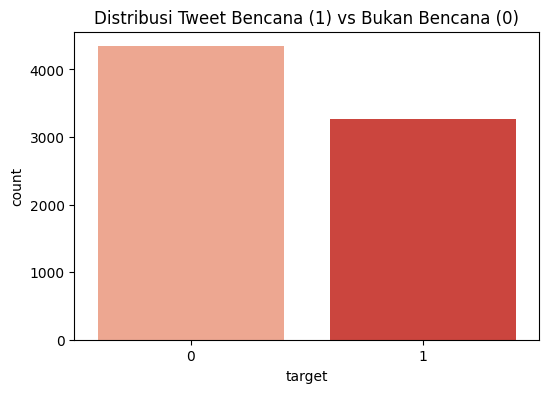

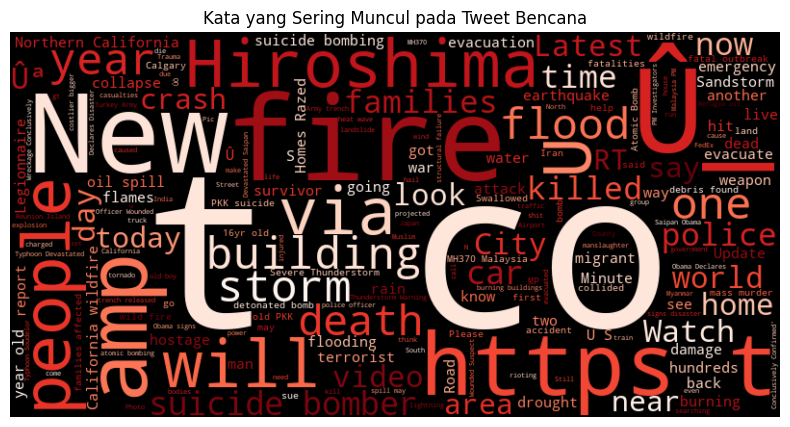

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Pastikan path sudah benar setelah download berhasil
train_df_text = pd.read_csv(os.path.join(path, 'train.csv'))

# --- 1. Distribusi Label (Disaster vs Non-Disaster) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=train_df_text, palette='Reds')
plt.title('Distribusi Tweet Bencana (1) vs Bukan Bencana (0)')
plt.show()

# --- 2. Word Cloud untuk Tweet Bencana ---
disaster_tweets = " ".join(train_df_text[train_df_text['target'] == 1]['text'])
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(disaster_tweets)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Kata yang Sering Muncul pada Tweet Bencana')
plt.show()

In [8]:
import re
import string
import tensorflow as tf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split

# --- 1. CLEANING FUNCTION ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Hapus Tanda Baca
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

train_df_text['text_clean'] = train_df_text['text'].apply(clean_text)

# --- 2. SPLIT DATA ---
X_text = train_df_text['text_clean']
y_text = train_df_text['target']

X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(X_text, y_text, test_size=0.2, random_state=42)

# --- 3. TF-IDF + LOGISTIC REGRESSION ---
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train_t)
X_val_tfidf = tfidf.transform(X_val_t)

lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_tfidf, y_train_t)

# Evaluasi F1-Score (Metrik Resmi)
lr_preds = lr_model.predict(X_val_tfidf)
print(f"Baseline TF-IDF + LR F1-Score: {f1_score(y_val_t, lr_preds):.4f}")

Baseline TF-IDF + LR F1-Score: 0.7563


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# --- 1. TOKENIZATION ---
max_words = 10000
max_len = 50
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_t)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_t), maxlen=max_len)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val_t), maxlen=max_len)

# --- 2. ARSITEKTUR Bi-LSTM ---
lstm_model = tf.keras.Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 3. TRAINING ---
print("Training LSTM..")
lstm_model.fit(X_train_seq, y_train_t, epochs=10, batch_size=32, 
               validation_data=(X_val_seq, y_val_t), verbose=1)

# Evaluasi F1-Score
lstm_probs = lstm_model.predict(X_val_seq)
lstm_preds = (lstm_probs > 0.5).astype(int)
print(f"Deep Learning LSTM F1-Score: {f1_score(y_val_t, lstm_preds):.4f}")

C:\Users\athay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training LSTM..
Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.7151 - loss: 0.5518 - val_accuracy: 0.7958 - val_loss: 0.4630
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8713 - loss: 0.3369 - val_accuracy: 0.7873 - val_loss: 0.4685
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9294 - loss: 0.2157 - val_accuracy: 0.7728 - val_loss: 0.6441
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 68ms/step - accuracy: 0.9522 - loss: 0.1483 - val_accuracy: 0.7636 - val_loss: 0.6210
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9690 - loss: 0.1038 - val_accuracy: 0.7492 - val_loss: 0.8789
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9711 - loss: 0.0792 - val_accuracy: 0.7446 - val_loss: 0.8470
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.9770 - loss: 0.0558 - val_accuracy: 0.7656 - val_loss: 1.3131
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.9767 - 

In [10]:

results_df = pd.DataFrame({
    'text': X_val_t,
    'actual': y_val_t,
    'lr_pred': lr_preds,
    'lstm_pred': lstm_preds.flatten()
})

# Contoh tweet di mana model konvensional salah
error_samples = results_df[results_df['actual'] != results_df['lr_pred']].head(3)
print("\nContoh Analisis Error (Konvensional):")
print(error_samples[['text', 'actual', 'lr_pred']])


Contoh Analisis Error (Konvensional):
                                                   text  actual  lr_pred
2644  so you have a new weapon that can cause unimag...       1        0
6845  in response to trauma children of addicts deve...       0        1
1765  my favorite lady came to our volunteer meeting...       1        0


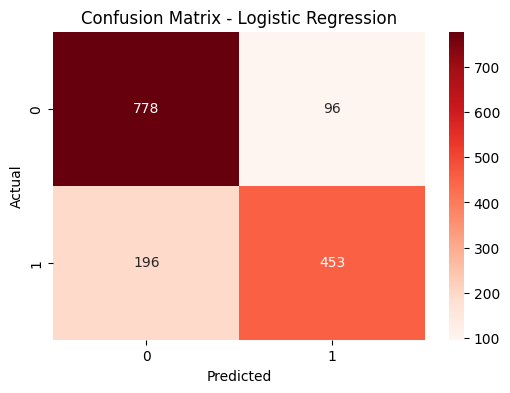

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val_t, lr_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()